In [1]:
base_dir = "/home/shaeo/cadd_training/20251004_OpenFE"

## 前処理

In [2]:
from pdbfixer import PDBFixer
from openmm.app import PDBFile

In [3]:
data_dir = base_dir + "/data"
pre_protein_path = data_dir + "/D3R/4YKQ_hsp90_40.pdb"
protein_path = data_dir + "/receptor_HSP90.pdb"

In [4]:
# PDBfixer
fixer = PDBFixer(filename=pre_protein_path)
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
fixer.removeHeterogens(keepWater=False)
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(pH=7.4)

In [5]:
with open(protein_path, "w") as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

## セットアップ

In [6]:
import os

In [7]:
# CUDA関連の設定（メモリリーク防止）
#os.environ["CUDA_DEVICE_MAX_CONNECTIONS"] = "1"     # GPUメモリ節約
#os.environ["CUDA_LAUNCH_BLOCKING"] = "1"            # 同期化で安定動作
#os.environ["OPENMM_DEFAULT_PLATFORM"] = "CUDA"      # OpenCLを避ける
#from openmmtools import cache
#cache.global_context_cache = cache.ContextCache(capacity=1)  # 最小キャッシュ

### リガンドの読み込み

In [8]:
from openfe import SmallMoleculeComponent
from rdkit import Chem
from openfe.protocols.openmm_utils.omm_settings import OpenFFPartialChargeSettings
from openfe.protocols.openmm_utils.charge_generation import bulk_assign_partial_charges

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/openmoltools/utils.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [9]:
# 設定
ligands_path = data_dir + "/ligands_HSP90.sdf"

In [10]:
# 読み込み
ligands_sdf = Chem.SDMolSupplier(ligands_path, removeHs=False)
ligand_mols = [SmallMoleculeComponent(sdf) for sdf in ligands_sdf]

In [11]:
# 電荷処理
charge_settings = OpenFFPartialChargeSettings(partial_charge_method="am1bcc", off_toolkit_backend="ambertools")

charged_ligands = bulk_assign_partial_charges(
    molecules=ligand_mols,
    overwrite=False,  
    method=charge_settings.partial_charge_method,
    toolkit_backend=charge_settings.off_toolkit_backend,
    generate_n_conformers=charge_settings.number_of_conformers,
    nagl_model=charge_settings.nagl_model,
    processors=1
)

Generating charges: 100%|█████████████████████████| 2/2 [00:12<00:00,  6.38s/it]


### リガンドネットワークの作成

In [12]:
import openfe
from kartograf import KartografAtomMapper
from openfe.setup.ligand_network_planning import generate_minimal_spanning_network as generate_mst_network
from openfe.utils.atommapping_network_plotting import plot_atommapping_network

In [13]:
# 設定
graphlm_path = data_dir + "/ligand_network.graphml"

In [14]:
# ネットワーク作成
mapper = openfe.LomapAtomMapper(max3d=1.0, element_change=False)
scorer = openfe.lomap_scorers.default_lomap_score
network_planner = generate_mst_network

ligand_network = generate_mst_network(
    ligands=ligand_mols,
    scorer=openfe.lomap_scorers.default_lomap_score,
    mappers=[KartografAtomMapper(),]
)

{'score': 0.6703200460356393}


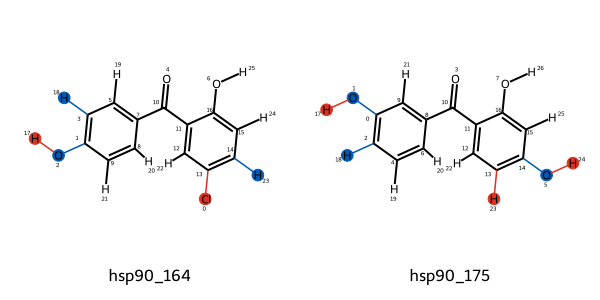

In [15]:
# エッジとスコアを表示
edges = list(ligand_network.edges)
mapping = edges[0]
print(mapping.annotations)
mapping

In [16]:
# GraphMLへの保存
with open(graphlm_path, "w") as f:
    f.write(ligand_network.to_graphml())

### アルケミカルネットワークの作成

In [17]:
from openfe import SolventComponent, ProteinComponent, ChemicalSystem
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openff.units import unit

In [18]:
# 設定
protein_path = data_dir + "/receptor_HSP90.pdb"
transformation_dir = base_dir + "/transformations"
os.makedirs(transformation_dir, exist_ok=True)

In [19]:
# コンポーネントの作成
protein = ProteinComponent.from_pdb_file(protein_path)
solvent = SolventComponent(
    positive_ion='Na', negative_ion='Cl',
    neutralize=True, ion_concentration=0.15*unit.molar
)

In [20]:
# プロトコルの作成
rbfe_settings = RelativeHybridTopologyProtocol.default_settings()
rbfe_settings.simulation_settings.equilibration_length = 0.5*unit.nanosecond
rbfe_settings.simulation_settings.production_length = 1*unit.nanosecond
rbfe_protocol = RelativeHybridTopologyProtocol(settings=rbfe_settings)

In [21]:
# アルケミカルネットワークの作成
transformations = []
for mapping in ligand_network.edges:
    for leg in ['solvent', 'complex']:
        
        # use the solvent and protein created above
        sysA_dict = {'ligand': mapping.componentA,
                     'solvent': solvent}
        sysB_dict = {'ligand': mapping.componentB,
                     'solvent': solvent}
        
        if leg == 'complex':
            sysA_dict['protein'] = protein
            sysB_dict['protein'] = protein
        
        # we don't have to name objects, but it can make things (like filenames) more convenient
        sysA = ChemicalSystem(sysA_dict, name=f"{mapping.componentA.name}_{leg}")
        sysB = ChemicalSystem(sysB_dict, name=f"{mapping.componentB.name}_{leg}")
        
        prefix = "rbfe_"  # prefix is only to exactly reproduce CLI
        
        transformation = openfe.Transformation(
            stateA=sysA,
            stateB=sysB,
            mapping={'ligand': mapping},
            protocol=rbfe_protocol,  # use protocol created above
            name=f"{prefix}{sysA.name}_{sysB.name}"
        )
        transformations.append(transformation)

network = openfe.AlchemicalNetwork(transformations)

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/gufe/transformations/transformation.py:196: DeprecationWarning: mapping input as a dict is deprecated; instead use either a single Mapping or list
  warnings.warn(
/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/gufe/transformations/transformation.py:196: DeprecationWarning: mapping input as a dict is deprecated; instead use either a single Mapping or list
  warnings.warn(


In [22]:
# jsonファイルへの書き出し
for transformation in network.edges:
    transformation.dump(transformation_dir + f"/{transformation.name}.json")

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(
/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(


In [23]:
# ファイルの確認
!ls transformations/

rbfe_hsp90_164_complex_hsp90_175_complex.json
rbfe_hsp90_164_solvent_hsp90_175_solvent.json


/home/shaeo/miniconda3/envs/openfe/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=737072) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


### ドライラン

In [24]:
#for transformation in transformations:
#    dry_dag  = transformation.create()  # 実行グラフへの展開
#    dry_unit = list(dry_dag.protocol_units)[0]  # 
#    dry_unit.run(dry=True, verbose=True)

## 実行

In [25]:
# 設定
list_input_json = [f for f in os.listdir(transformation_dir)]
result_dir = base_dir + "/result"
os.makedirs(result_dir, exist_ok=True)

In [26]:
# 実行
for input_json in list_input_json:
    
    name = input_json.split(".")[0]
    working_dir = result_dir + f"/{name}"
    os.makedirs(working_dir, exist_ok=True)
    
    input_path = transformation_dir + f"/{input_json}"
    result_path = result_dir + f"/{name}.json"
    
    !openfe quickrun $input_path -o $result_path -d $working_dir

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=737072) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/openmoltools/utils.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Loading file...
Planning simulations for this edge...
Element change in mapping between atoms Ligand A: 2 (element 8) and Ligand B: 18 (element 1)
No mass scaling is attempted in the hybrid topology, the average mass of the two atoms will be used in the simulation
Element change in mapping between atoms Ligand A: 18 (element 1) and Ligand B: 1 (element 8)
No mass scaling is attempted in the hybrid topology, the average mass of the two atoms will be used in the simulation
Element change in mapping between atoms Ligand A: 23 (element 1) and Ligand B: 5 (element 8)
No mass scaling is attempted in the hybrid topology, t

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=737072) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/openmoltools/utils.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Loading file...
Planning simulations for this edge...
Element change in mapping between atoms Ligand A: 2 (element 8) and Ligand B: 18 (element 1)
No mass scaling is attempted in the hybrid topology, the average mass of the two atoms will be used in the simulation
Element change in mapping between atoms Ligand A: 18 (element 1) and Ligand B: 1 (element 8)
No mass scaling is attempted in the hybrid topology, the average mass of the two atoms will be used in the simulation
Element change in mapping between atoms Ligand A: 23 (element 1) and Ligand B: 5 (element 8)
No mass scaling is attempted in the hybrid topology, t

## 解析

In [27]:
# ddGを算出
!openfe gather $result_dir/ --report ddg -o $result_dir/final_results.tsv

/home/shaeo/miniconda3/envs/openfe/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=737072) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


/home/shaeo/miniconda3/envs/openfe/lib/python3.13/site-packages/openmoltools/utils.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
writing ddg output to '/home/shaeo/cadd_training/20251004_OpenFE/result/final_results.tsv'
